In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv("data/processed/bitcoin_processed.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.set_index("timestamp", inplace=True)

data = df["close"]

In [3]:
train = data[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]

In [4]:
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()

c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
forecast = model_fit.forecast(steps=len(test))

In [6]:
import os
sarima_pred = pd.DataFrame(forecast)

sarima_pred.columns = ["prediction"]

os.makedirs("../results", exist_ok=True)

sarima_pred.to_csv("../results/sarima_predictions.csv", index=False)

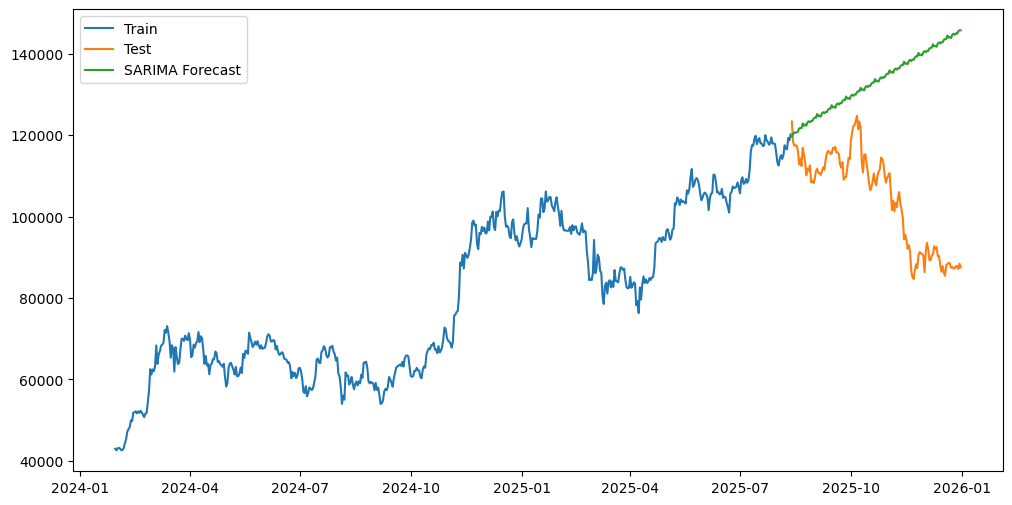

In [8]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="SARIMA Forecast")

plt.legend()
plt.show()